# Cluster Quilting: Spectral Clustering for Patchwork Learning

Implementation based on Zheng, Chang & Allen (2024).  
Dataset: `trialdf_24sessions.csv` — mouse facial landmark measurements across 24 sessions.

## 1. Setup & Data Loading

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('trialdf_24sessions.csv', index_col=0)
meta_cols = ['valence', 'airstart', 'sucstart', 'ms_id', 'condition', 'inj_site', 'ms_n']
feature_cols = [c for c in df.columns if c not in meta_cols]
df = df.loc[~df['valence'].str.contains('CS')]

print(f'Original shape: {df.shape}')
print(f'Feature columns: {len(feature_cols)}')
df.head()

Original shape: (129603, 128)
Feature columns: 121


,upper_eye_lower_eye_dist,upper_eye_inner_eye_dist,upper_eye_outer_eye_dist,upper_eye_nose_upper_dist,upper_eye_nose_tip_dist,upper_eye_nostril_left_dist,upper_eye_nostril_right_dist,upper_eye_mouth_upper_dist,upper_eye_mouth_lower_dist,upper_eye_top_whisker_stem_dist,...,nose_tip_nostril_left_nostril_right_area,nostril_left_nostril_right_mouth_upper_area,bottom_whisker_stem_nostril_right_mouth_upper_area,valence,airstart,sucstart,ms_id,condition,inj_site,ms_n
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
390,76.569358,67.515555,71.015525,336.644874,365.292078,363.804458,345.746903,330.845185,338.200907,219.694124,...,187.826591,784.109647,8766.310867,ITI,0,0,20231101_CEM_005_670,Sated,CEM,5
391,76.573866,67.540966,71.015681,335.850135,367.409539,365.304756,345.126300,329.878244,338.180291,216.980328,...,201.177468,975.801986,8715.323246,ITI,0,0,20231101_CEM_005_670,Sated,CEM,5
392,76.563183,67.551363,71.026033,337.630875,371.770311,369.691262,345.426889,329.963256,338.202626,214.546853,...,252.272451,1306.982038,8816.186544,ITI,0,0,20231101_CEM_005_670,Sated,CEM,5
393,76.571178,67.554903,71.032975,338.403640,374.616301,371.953744,346.095840,330.605370,338.218859,213.715551,...,291.778025,1435.171385,8854.551825,ITI,0,0,20231101_CEM_005_670,Sated,CEM,5
394,76.605934,67.737194,70.887837,338.891496,375.768898,373.349753,347.116544,331.737347,338.342377,214.095262,...,298.907967,1507.848485,8845.675657,ITI,0,0,20231101_CEM_005_670,Sated,CEM,5


## 2. Data Cleaning

1. Drop feature columns with >5% NaN
2. Drop any remaining rows with NaN
3. If the dataset shrank, save cleaned result as `.npz`

In [12]:
n_rows_orig, n_feat_orig = len(df), len(feature_cols)

# Step 1: drop feature columns with >5% NaN
nan_frac = df[feature_cols].isnull().mean()
cols_to_drop = nan_frac[nan_frac > 0.05].index.tolist()
if cols_to_drop:
    print(f'Dropping {len(cols_to_drop)} columns with >5% NaN: {cols_to_drop}')
    feature_cols = [c for c in feature_cols if c not in cols_to_drop]
else:
    print('No columns exceed 5% NaN threshold.')

# Step 2: drop rows with any remaining NaN in feature columns
rows_before = len(df)
df = df.dropna(subset=feature_cols)
rows_dropped = rows_before - len(df)
if rows_dropped > 0:
    print(f'Dropped {rows_dropped} rows with NaN.')
else:
    print('No rows contain NaN.')

# Summary
dataset_shrank = (len(feature_cols) < n_feat_orig) or (len(df) < n_rows_orig)
print(f'\nCleaned shape: {df.shape} | Features: {len(feature_cols)}')
print(f'Dataset shrank: {dataset_shrank}')

if dataset_shrank:
    np.savez('trialdf_cleaned.npz',
             features=df[feature_cols].values,
             feature_names=np.array(feature_cols),
             valence=df['valence'].values,
             condition=df['condition'].values,
             inj_site=df['inj_site'].values,
             ms_id=df['ms_id'].values)
    print('Saved cleaned data to trialdf_cleaned.npz')
else:
    print('Dataset is already complete — no npz export needed.')

No columns exceed 5% NaN threshold.
No rows contain NaN.

Cleaned shape: (129603, 128) | Features: 121
Dataset shrank: False
Dataset is already complete — no npz export needed.


## 3. Standardization

Apply `StandardScaler` if features do not already have mean ~0 and std ~1.

In [13]:
X = df[feature_cols].values
means = X.mean(axis=0)
stds = X.std(axis=0)

already_scaled = np.allclose(means, 0, atol=1e-2) and np.allclose(stds, 1, atol=1e-2)

if already_scaled:
    print('Features already have mean ~0 and std ~1 — skipping scaling.')
    X_scaled = X
else:
    print(f'Before scaling — mean range: [{means.min():.2f}, {means.max():.2f}], '
          f'std range: [{stds.min():.2f}, {stds.max():.2f}]')
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    print(f'After scaling  — mean range: [{X_scaled.mean(axis=0).min():.2e}, {X_scaled.mean(axis=0).max():.2e}], '
          f'std range: [{X_scaled.std(axis=0).min():.4f}, {X_scaled.std(axis=0).max():.4f}]')

Before scaling — mean range: [0.11, 11657.87], std range: [0.03, 1367.27]
After scaling  — mean range: [-1.12e-14, 7.47e-15], std range: [1.0000, 1.0000]


## 4. PCA & Visualization

Fit PCA on the scaled features, then plot the top 3 PCs in 3D colored by valence.
Subsample to 1000 points per valence category for a balanced plot.

In [14]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print(f'Total variance explained by 3 PCs: {pca.explained_variance_ratio_.sum():.4f}')

Explained variance ratio: [0.29396279 0.22280615 0.07904671]
Total variance explained by 3 PCs: 0.5958


In [15]:
# Subsample: 1000 points per valence category
valence = df['valence'].values
categories = np.unique(valence)
n_per_cat = 1000

rng = np.random.default_rng(42)
sample_idx = []
for cat in categories:
    cat_idx = np.where(valence == cat)[0]
    chosen = rng.choice(cat_idx, size=min(n_per_cat, len(cat_idx)), replace=False)
    sample_idx.append(chosen)
sample_idx = np.concatenate(sample_idx)

X_plot = X_pca[sample_idx]
valence_plot = valence[sample_idx]


print(f'Plotting {len(sample_idx)} points ({n_per_cat} per category)')
for cat in categories:
    print(f'  {cat}: {(valence_plot == cat).sum()}')

Plotting 3000 points (1000 per category)
  Air_US: 1000
  ITI: 1000
  Sucrose_US: 1000


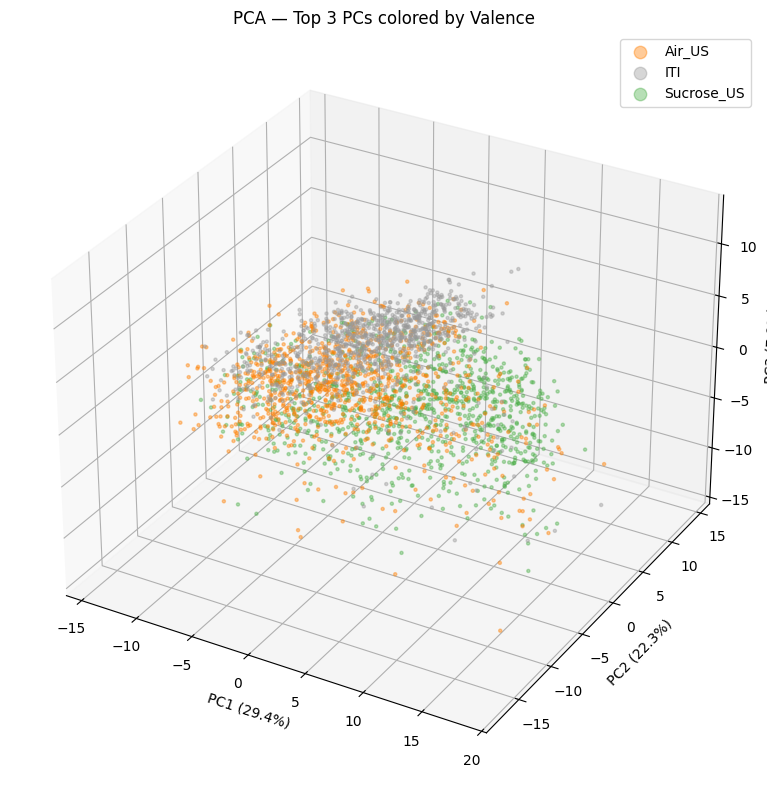

In [16]:
# 3D scatter plot colored by valence
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

colors = {'Air_CS': '#e41a1c', 'Air_US': '#ff7f00',
          'ITI': '#999999',
          'Sucrose_CS': '#377eb8', 'Sucrose_US': '#4daf4a'}

for cat in categories:
    mask = valence_plot == cat
    ax.scatter(X_plot[mask, 0], X_plot[mask, 1], X_plot[mask, 2],
              s=5, alpha=0.4, label=cat, color=colors.get(cat, '#000000'))

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]:.1%})')
ax.set_title('PCA — Top 3 PCs colored by Valence')
ax.legend(markerscale=4)

plt.tight_layout()
plt.show()

## 4b. K-Means on PCA — Full Data Baseline

Run k-means (K=5) on the PCA-projected data to establish an upper bound for clustering performance.
This uses **all** features and **all** samples — no patchwork missingness.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

K = len(categories)

# Sweep over number of PCA components
print(f'K-Means (K={K}) on PCA-projected full data\n')
print(f'{"n_pcs":>6}  {"ARI":>8}  {"NMI":>8}')
print('-' * 28)
best_ari, best_npc = -1, 0
for n_pcs in [2, 3, 4, 5, 10, 20, 50]:
    pca_k = PCA(n_components=n_pcs)
    X_pca_k = pca_k.fit_transform(X_scaled)
    km = KMeans(n_clusters=K, n_init=20, random_state=42)
    labels_km = km.fit_predict(X_pca_k)
    ari = adjusted_rand_score(valence, labels_km)
    nmi = normalized_mutual_info_score(valence, labels_km)
    if ari > best_ari:
        best_ari, best_npc = ari, n_pcs
        best_labels = labels_km
    print(f'{n_pcs:>6}  {ari:>8.4f}  {nmi:>8.4f}')

print(f'\nBest: n_pcs={best_npc}, ARI={best_ari:.4f}')

# Confusion table for best result
print(f'\nCluster composition (n_pcs={best_npc}):')
print(f'{"":>10}', end='')
for cat in categories:
    print(f'{cat:>14}', end='')
print()
for k in range(K):
    mask = best_labels == k
    print(f'Cluster {k}:', end='')
    for cat in categories:
        count = np.sum((valence == cat) & mask)
        print(f'{count:>14}', end='')
    print(f'  (total: {mask.sum()})')

K-Means (K=3) on PCA-projected full data

 n_pcs       ARI       NMI
----------------------------
     2    0.1795    0.1520
     3    0.1850    0.1564
     4    0.1836    0.1557
     5    0.1845    0.1562
    10    0.1858    0.1571
    20    0.1850    0.1571
    50    0.1853    0.1572

Best: n_pcs=10, ARI=0.1858

Cluster composition (n_pcs=10):
                  Air_US           ITI    Sucrose_US
Cluster 0:         10956         20946         12313  (total: 44215)
Cluster 1:          4182          3536         23596  (total: 31314)
Cluster 2:          4130         40660          9284  (total: 54074)


## 5. LDA — Maximally Separating Projection

PCA maximizes variance regardless of class labels. **Linear Discriminant Analysis (LDA)** instead finds the projection that maximizes the ratio of between-class to within-class scatter — i.e., it finds the basis that makes class separation as obvious as possible. With 5 valence categories, LDA yields 4 discriminant axes; we plot the top 3.

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, valence)

print('LDA explained variance ratio:', lda.explained_variance_ratio_)
print(f'Total ratio in top 2 LDs: {lda.explained_variance_ratio_.sum():.4f}')

LDA explained variance ratio: [0.69404359 0.30595641]
Total ratio in top 3 LDs: 1.0000


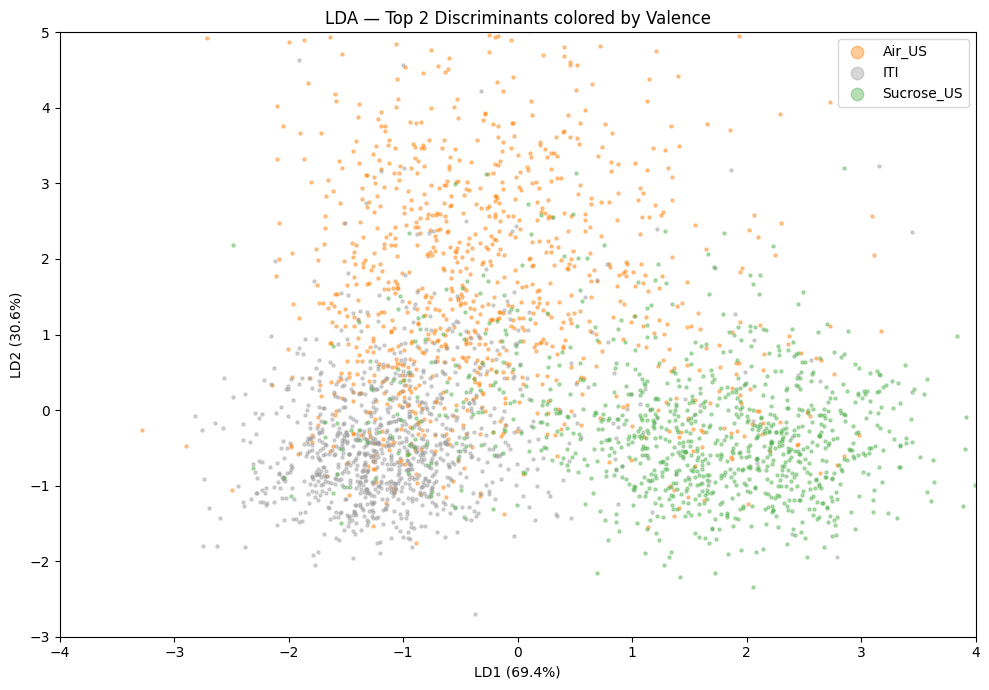

In [22]:
# Reuse the same balanced subsample from Section 4
X_lda_plot = X_lda[sample_idx]

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'Air_CS': '#e41a1c', 'Air_US': '#ff7f00',
          'ITI': '#999999',
          'Sucrose_CS': '#377eb8', 'Sucrose_US': '#4daf4a'}

for cat in categories:
    mask = valence_plot == cat
    ax.scatter(X_lda_plot[mask, 0], X_lda_plot[mask, 1],
              s=5, alpha=0.4, label=cat, color=colors.get(cat, '#000000'))

ax.set_xlabel(f'LD1 ({lda.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'LD2 ({lda.explained_variance_ratio_[1]:.1%})')
ax.set_title('LDA — Top 2 Discriminants colored by Valence')
ax.set_xlim(-4, 4)
ax.set_ylim(-3, 5)
ax.legend(markerscale=4)

plt.savefig('./plots/lda_valence.png', dpi=300)
plt.tight_layout()
plt.show()